Two sources:
1. `src/dictionary_collection/mturk/analysis`
2. `src/data_term_gold/processed`

In [1]:
import pandas as pd
import json
data_gold = pd.read_json("/home/jiaruil5/multilingual/multilingual-model-card/src/data_term_gold/processed/french.json").rename(columns={"term_reformatted": "word", "term_french_reformatted": "validated_translation"}, inplace=False).drop_duplicates(subset='word', inplace=False)
data_gold['word_lower'] = data_gold['word'].str.lower()
data_6060 = pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_results_6060/French_validated.csv").drop_duplicates(subset='word', inplace=False)
data_mturk = pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_results_crawled/French_validated.csv").drop_duplicates(subset='word', inplace=False)

In [2]:
concat_df = pd.concat([data_6060[['word', 'validated_translation']], data_mturk[['word', 'validated_translation']]], axis=0, ignore_index=True)
concat_df['word_lower'] = concat_df['word'].str.lower()
concat_df

,word,validated_translation,word_lower
0,AI,IA,ai
1,API,API,api
2,AQA,AQA,aqa
3,ARENA,ARENA,arena
4,Additionally,De plus,additionally
...,...,...,...
4985,zero-shot prompting,amorçage sans exemple préalable,zero-shot prompting
4986,zero-shot reasoning,raisonnement sans exemple préalable,zero-shot reasoning
4987,zero-shot setting,contexte sans exemples,zero-shot setting
4988,zero-shot transfer,transfert zéro-shot,zero-shot transfer


In [3]:
df_itst = pd.merge(data_gold[['word', 'word_lower', 'validated_translation']], concat_df[['word', 'word_lower', 'validated_translation']], on='word_lower')
df_itst[df_itst['validated_translation_x'] == df_itst['validated_translation_y']].shape[0] / df_itst.shape[0], df_itst[df_itst['validated_translation_x'] == df_itst['validated_translation_y']].shape[0], df_itst.shape[0]

(0.483065953654189, 271, 561)

In [9]:
def levenshtein_distance(str1, str2):
    # Initialize matrix of distances
    dp = [[0] * (len(str2) + 1) for _ in range(len(str1) + 1)]

    # Base cases
    for i in range(len(str1) + 1):
        dp[i][0] = i
    for j in range(len(str2) + 1):
        dp[0][j] = j

    # Fill the matrix
    for i in range(1, len(str1) + 1):
        for j in range(1, len(str2) + 1):
            if str1[i - 1] == str2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]  # No operation needed
            else:
                dp[i][j] = min(dp[i - 1][j] + 1,      # Deletion
                               dp[i][j - 1] + 1,      # Insertion
                               dp[i - 1][j - 1] + 1)  # Substitution

    # The distance is in the bottom-right cell
    return dp[-1][-1]

df_itst['levenshtein_dist'] = df_itst.apply(lambda x: levenshtein_distance(x['validated_translation_x'], x['validated_translation_y']), axis=1)

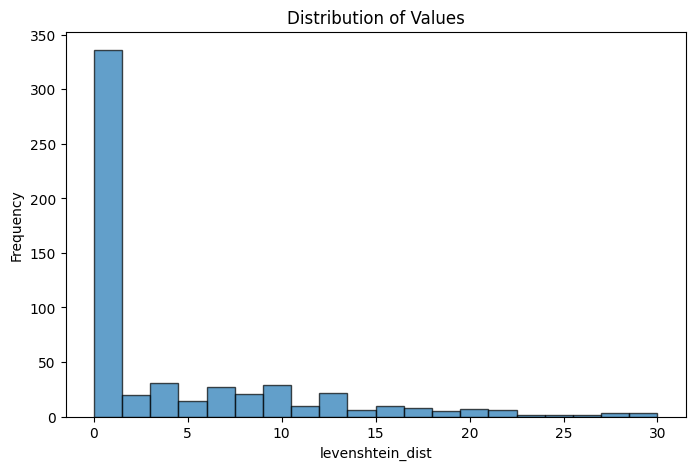

In [11]:
import matplotlib.pyplot as plt
import pandas as pd


# Plot the distribution of the 'values' column
plt.figure(figsize=(8, 5))
plt.hist(df_itst['levenshtein_dist'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('levenshtein_dist')
plt.ylabel('Frequency')
plt.title('Distribution of Values')
plt.show()


In [4]:
merged_df = pd.merge(concat_df[['word', 'word_lower', 'validated_translation']], data_gold[['word', 'word_lower', 'validated_translation']], on="word_lower", how='outer', suffixes=('_df2', '_df1'))
merged_df

,word_df2,word_lower,validated_translation_df2,word_df1,validated_translation_df1
0,10-fold cross validation,10-fold cross validation,validation croisée à 10 plis,NaN,NaN
1,1D convolution,1d convolution,convolution 1D,NaN,NaN
2,2 norm,2 norm,norme 2,NaN,NaN
3,NaN,2 x 2 contingency table,NaN,2 x 2 contingency table,table de contingence 2 x 2
4,2D convolution,2d convolution,convolution 2D,NaN,NaN
...,...,...,...,...,...
6742,Zipf,zipf,Zipf,NaN,NaN
6743,Zipf distribution,zipf distribution,distribution de Zipf,NaN,NaN
6744,Zipf's law,zipf's law,loi de Zipf,Zipf's law,loi de Zipf
6745,NaN,ŷ,NaN,ŷ,y hat


In [5]:
merged_df['validated_translation'] = merged_df['validated_translation_df1'].combine_first(merged_df['validated_translation_df2'])
merged_df['word'] = merged_df['word_df1'].combine_first(merged_df['word_df2'])
merged_df

,word_df2,word_lower,validated_translation_df2,word_df1,validated_translation_df1,validated_translation,word
0,10-fold cross validation,10-fold cross validation,validation croisée à 10 plis,NaN,NaN,validation croisée à 10 plis,10-fold cross validation
1,1D convolution,1d convolution,convolution 1D,NaN,NaN,convolution 1D,1D convolution
2,2 norm,2 norm,norme 2,NaN,NaN,norme 2,2 norm
3,NaN,2 x 2 contingency table,NaN,2 x 2 contingency table,table de contingence 2 x 2,table de contingence 2 x 2,2 x 2 contingency table
4,2D convolution,2d convolution,convolution 2D,NaN,NaN,convolution 2D,2D convolution
...,...,...,...,...,...,...,...
6742,Zipf,zipf,Zipf,NaN,NaN,Zipf,Zipf
6743,Zipf distribution,zipf distribution,distribution de Zipf,NaN,NaN,distribution de Zipf,Zipf distribution
6744,Zipf's law,zipf's law,loi de Zipf,Zipf's law,loi de Zipf,loi de Zipf,Zipf's law
6745,NaN,ŷ,NaN,ŷ,y hat,y hat,ŷ


In [6]:
ref_df = pd.concat([pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_final/Chinese.csv"), pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_final/Arabic.csv"), pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_final/Russian.csv"), pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_final/Japanese.csv")], axis=0).drop_duplicates(subset='word', inplace=False)
ref_df['word_lower'] = ref_df['word'].str.lower()

In [7]:
merged_df = merged_df[['word', 'validated_translation']].drop_duplicates(subset='word', inplace=False).sort_values(by='word')
merged_df['word_lower'] = merged_df['word'].str.lower()

merged = merged_df.merge(ref_df[['word', 'word_lower']], on='word_lower', how='left', suffixes=('', '_ref'))

# Update 'word' in merged_df with the 'word' from ref_df where it matches
merged['word'] = merged['word_ref'].combine_first(merged['word'])

# Drop the temporary 'word_ref' column used for merging
merged = merged.drop(columns=['word_ref'])
merged

,word,validated_translation,word_lower
0,10-fold cross validation,validation croisée à 10 plis,10-fold cross validation
1,1D convolution,convolution 1D,1d convolution
2,2 norm,norme 2,2 norm
3,2 x 2 contingency table,table de contingence 2 x 2,2 x 2 contingency table
4,2D convolution,convolution 2D,2d convolution
...,...,...,...
6743,zero-shot transfer,transfert zéro-shot,zero-shot transfer
6744,zero-shot transfer learning,apprentissage par transfert zéro-shot,zero-shot transfer learning
6745,zettabyte,zettaoctet,zettabyte
6746,ŷ,y hat,ŷ


In [8]:
merged = merged.drop_duplicates(subset='word_lower', inplace=False)[['word', 'validated_translation']].sort_values(by='word')
merged.to_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_final/French.csv")